In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/Paula/OneDrive/Documentos/8 SEMESTRE/CIENCIA DE DATOS II/data.csv")

In [5]:
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df = df.drop(columns=["id", "Unnamed: 32"])

df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

print(df.head())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          

In [7]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [9]:

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])


pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])


pipe_tree = Pipeline([
    ("model", DecisionTreeClassifier())
])

In [10]:
modelos = {
    "Logistic Regression": pipe_lr,
    "KNN": pipe_knn,
    "Decision Tree": pipe_tree
}

In [11]:
resultados = []

for nombre, modelo in modelos.items():

    
    modelo.fit(X_train, y_train)

    
    pred_train = modelo.predict_proba(X_train)[:,1]

    auc_train = roc_auc_score(
        y_train,
        pred_train
    )

    
    pred_valid = modelo.predict_proba(X_valid)[:,1]

    auc_valid = roc_auc_score(
        y_valid,
        pred_valid
    )

    
    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=kf,
        scoring="roc_auc"
    )


    resultados.append({
        "Modelo": nombre,
        "Train ROC AUC": auc_train,
        "Validation ROC AUC": auc_valid,
        "CV Mean": scores.mean(),
        "CV Std": scores.std()
    })

    print(nombre)
    print(scores)
    print("----------------------")

Logistic Regression
[1.         0.99074074 0.99407505 0.98367347 0.99663978]
----------------------
KNN
[0.999      0.99679487 0.95786702 0.9585034  0.99731183]
----------------------
Decision Tree
[0.92       0.91524217 0.88874259 0.96292517 0.93649194]
----------------------


In [12]:
resultados_df = pd.DataFrame(resultados)

print(resultados_df)

                Modelo  Train ROC AUC  Validation ROC AUC   CV Mean    CV Std
0  Logistic Regression       0.997243            1.000000  0.993026  0.005577
1                  KNN       0.997459            0.992832  0.981895  0.019374
2        Decision Tree       1.000000            0.891577  0.924680  0.024514


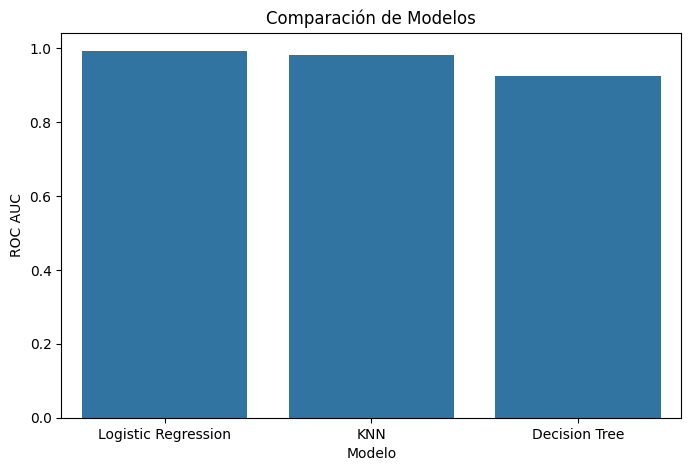

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="CV Mean"
)

plt.title("Comparación de Modelos")
plt.ylabel("ROC AUC")

plt.show()

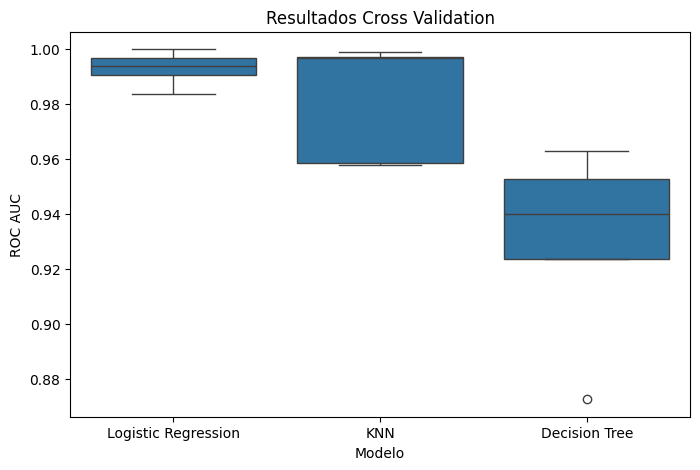

In [14]:
cv_resultados = []

for nombre, modelo in modelos.items():

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=kf,
        scoring="roc_auc"
    )

    for score in scores:

        cv_resultados.append({
            "Modelo": nombre,
            "ROC AUC": score
        })

cv_df = pd.DataFrame(cv_resultados)


plt.figure(figsize=(8,5))

sns.boxplot(
    data=cv_df,
    x="Modelo",
    y="ROC AUC"
)

plt.title("Resultados Cross Validation")

plt.show()

In [15]:
mejor_modelo = pipe_lr

In [16]:
X_train_final = pd.concat([X_train, X_valid])

y_train_final = pd.concat([y_train, y_valid])

mejor_modelo.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [17]:
pred_test = mejor_modelo.predict_proba(X_test)[:,1]

auc_test = roc_auc_score(
    y_test,
    pred_test
)

print("ROC AUC TEST")

print(auc_test)

ROC AUC TEST
0.9959977129788451


# Conclusiones 
- En este trabajo se compararon tres modelos diferentes para mirar cuál funcionaba mejor con el dataset de cáncer de mama.
- El modelo de Logistic Regression fue el que tuvo resultados más parecidos entre entrenamiento, validación y test, por eso se escogió como el mejor modelo.
- KNN también tuvo buenos resultados, aunque en algunas pruebas cambiaba más dependiendo de los datos utilizados.
- La validación cruzada ayudó bastante porque permitió evaluar el modelo varias veces y no solamente con una sola partición de los datos.
- En general, el trabajo ayudó a entender que no siempre el modelo con mejor resultado en entrenamiento es el mejor, sino el que logra generalizar mejor con datos nuevos.